# 5 — Visualización orientada a preguntas

Un gráfico no es el objetivo: es evidencia para responder una pregunta. En cada ejercicio primero escribí qué querés averiguar, luego construí la agregación y finalmente redactá una conclusión de dos o tres oraciones.

Este notebook se ejecuta manualmente **después** de que el Job termina correctamente; no forma parte del pipeline.

In [0]:
dbutils.widgets.text("student_id", "alumno01", "01 - Identificador")
dbutils.widgets.dropdown("scale", "small", ["test", "small", "demo"], "02 - Escala")

In [0]:
%run ../common/config

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

catalog = spark.sql("SELECT current_catalog()").first()[0]
config = CourseConfig(catalog, dbutils.widgets.get("student_id"), dbutils.widgets.get("scale"))
daily = qualified_table(config, "gold_daily_sales")
risk = qualified_table(config, "gold_customer_risk")
batch = qualified_table(config, "gold_batch_summary")
for table in [daily, risk, batch]:
    assert spark.catalog.tableExists(table), f"Falta {table}. Ejecutá primero el Job completo."

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-7119794578096269>, line 5
      2 import matplotlib.pyplot as plt
      4 catalog = spark.sql("SELECT current_catalog()").first()[0]
----> 5 config = CourseConfig(catalog, dbutils.widgets.get("student_id"), dbutils.widgets.get("scale"))
      6 daily = qualified_table(config, "gold_daily_sales")
      7 risk = qualified_table(config, "gold_customer_risk")

NameError: name 'CourseConfig' is not defined

## Ejemplo resuelto

**Pregunta:** ¿Qué categoría concentra el mayor monto vendido?

La agregación se hace con Spark. Sólo el resultado pequeño se convierte a Pandas para dibujarlo. Un gráfico de barras ordenado permite comparar categorías; un gráfico de torta haría más difícil comparar valores cercanos.

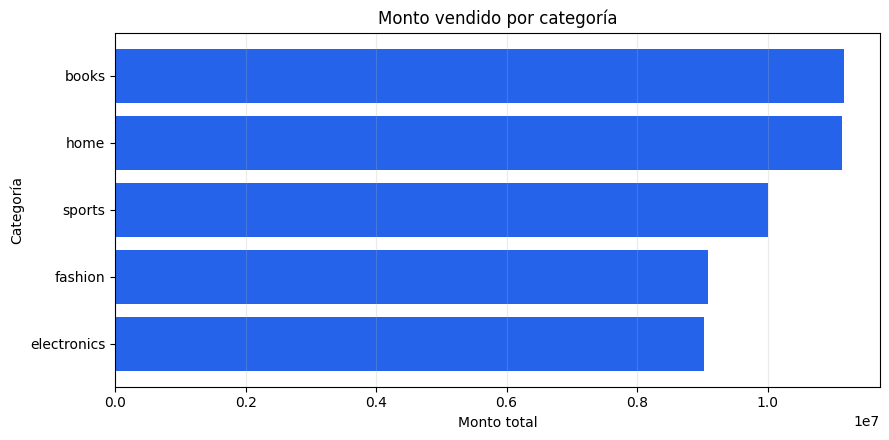

Respuesta: books es la categoría con mayor monto vendido (11,165,281.86).


In [0]:
category_sales = (spark.table(daily)
    .groupBy("category")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy(F.desc("total_amount")))

plot_data = category_sales.toPandas().sort_values("total_amount")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_data["category"], plot_data["total_amount"], color="#2563eb")
ax.set_title("Monto vendido por categoría")
ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

leader = category_sales.first()
print(f"Respuesta: {leader.category} es la categoría con mayor monto vendido ({leader.total_amount:,.2f}).")

## Consigna 1 — Evolución temporal

**Pregunta:** ¿Qué día tuvo el mayor monto vendido y ese día también fue el de mayor cantidad de transacciones?

Construí una visualización temporal que permita comparar ambas métricas sin ocultar sus unidades. Explicá si los dos máximos coinciden y qué implica que coincidan —o no— sobre el ticket promedio. Fuente sugerida: `gold_daily_sales`.

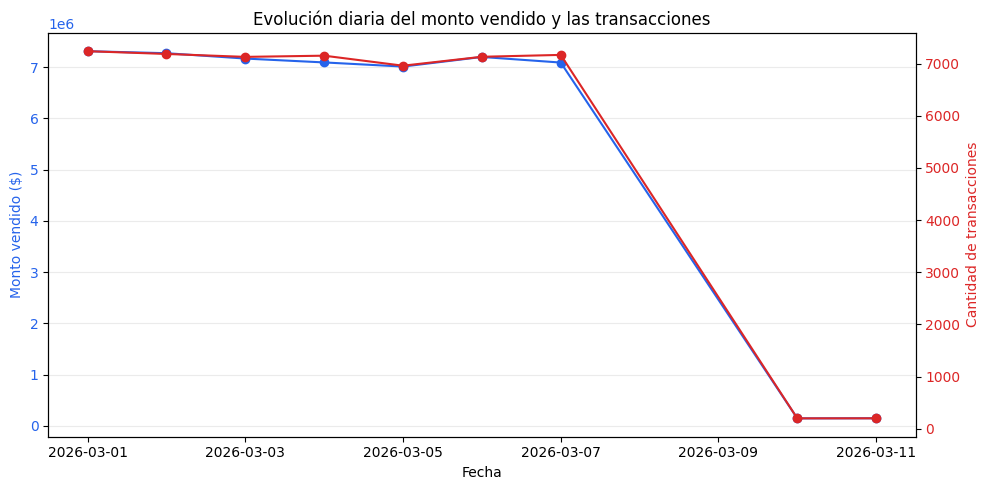

Mayor monto vendido: 2026-03-01 ($7,310,840.77)
Mayor cantidad de transacciones: 2026-03-01 (7,236)
Respuesta: los dos máximos coinciden en la misma fecha. Esto indica que el día con mayor monto vendido también tuvo la mayor cantidad de transacciones. Sin embargo, esto no implica necesariamente que haya tenido el mayor ticket promedio.


In [0]:
# Tu solución. Agregá por sale_date antes de convertir el resultado a Pandas.
# Incluí título, ejes, unidades y una respuesta escrita.
# Agregamos por fecha antes de convertir a Pandas
daily_sales = (spark.table(daily)
    .groupBy("sale_date")
    .agg(
        F.sum("total_amount").alias("total_amount"),
        F.sum("transaction_count").alias("transaction_count")
    )
    .orderBy("sale_date"))

# Convertimos a Pandas para graficar
plot_data = daily_sales.toPandas()

# Gráfico con dos ejes para no mezclar unidades
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    plot_data["sale_date"],
    plot_data["total_amount"],
    marker="o",
    color="#2563eb",
    label="Monto vendido"
)

ax1.set_xlabel("Fecha")
ax1.set_ylabel("Monto vendido ($)", color="#2563eb")
ax1.tick_params(axis="y", labelcolor="#2563eb")

ax2 = ax1.twinx()

ax2.plot(
    plot_data["sale_date"],
    plot_data["transaction_count"],
    marker="o",
    color="#dc2626",
    label="Cantidad de transacciones"
)

ax2.set_ylabel("Cantidad de transacciones", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")

ax1.set_title("Evolución diaria del monto vendido y las transacciones")
ax1.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

# Buscamos los máximos
max_amount = daily_sales.orderBy(F.desc("total_amount")).first()
max_transactions = daily_sales.orderBy(F.desc("transaction_count")).first()

# Respuesta escrita
print(f"Mayor monto vendido: {max_amount.sale_date} (${max_amount.total_amount:,.2f})")
print(f"Mayor cantidad de transacciones: {max_transactions.sale_date} ({max_transactions.transaction_count:,})")

if max_amount.sale_date == max_transactions.sale_date:
    print(
        "Respuesta: los dos máximos coinciden en la misma fecha. "
        "Esto indica que el día con mayor monto vendido también tuvo la mayor "
        "cantidad de transacciones. Sin embargo, esto no implica necesariamente "
        "que haya tenido el mayor ticket promedio."
    )
else:
    print(
        "Respuesta: los dos máximos no coinciden. Esto indica que el día con "
        "mayor monto vendido y el día con mayor cantidad de transacciones son "
        "diferentes, lo que sugiere diferencias en el ticket promedio entre ambos días."
    )



## Consigna 2 — Canal y fraude

**Pregunta:** ¿Qué canal de pago presenta la mayor tasa de fraude? ¿La conclusión se sostiene al considerar el número de transacciones de cada canal?

Mostrá tasa y volumen de manera legible. No compares sólo cantidades de fraude: calculá el denominador correcto. Fuente sugerida: `gold_daily_sales`.

In [0]:
from pyspark.sql import functions as F

channel_fraud = (spark.table("bigdata_alejo_escalada1.gold_daily_sales")
    .groupBy("payment_channel")
    .agg(
        F.sum("fraud_transactions").alias("fraud_transactions"),
        F.sum("transaction_count").alias("transaction_count")
    )
    .withColumn(
        "fraud_rate",
        F.col("fraud_transactions") / F.col("transaction_count") * 100
    )
    .orderBy(F.desc("fraud_rate")))

display(channel_fraud)
print ("El canal que mas fraude de pagos tiene es el de transferencia, tambien es el que tiene un peor fraud rate")


payment_channel,fraud_transactions,transaction_count,fraud_rate
transfer,2327,16723,13.91496741015368
wallet,2169,16724,12.969385314518059
card,2119,16902,12.536977872441133


El canal que mas fraude de pagos tiene es el de transferencia, tambien es el que tiene un peor fraud rate


## Consigna 3 — Concentración geográfica y de producto

**Pregunta:** ¿Qué combinación de país y categoría genera el mayor monto? ¿Existe una categoría dominante en todos los países o cambia según el mercado?

Elegí una visualización que permita comparar simultáneamente países y categorías. Justificá brevemente por qué ese tipo de gráfico es adecuado. Fuente sugerida: `gold_daily_sales`.

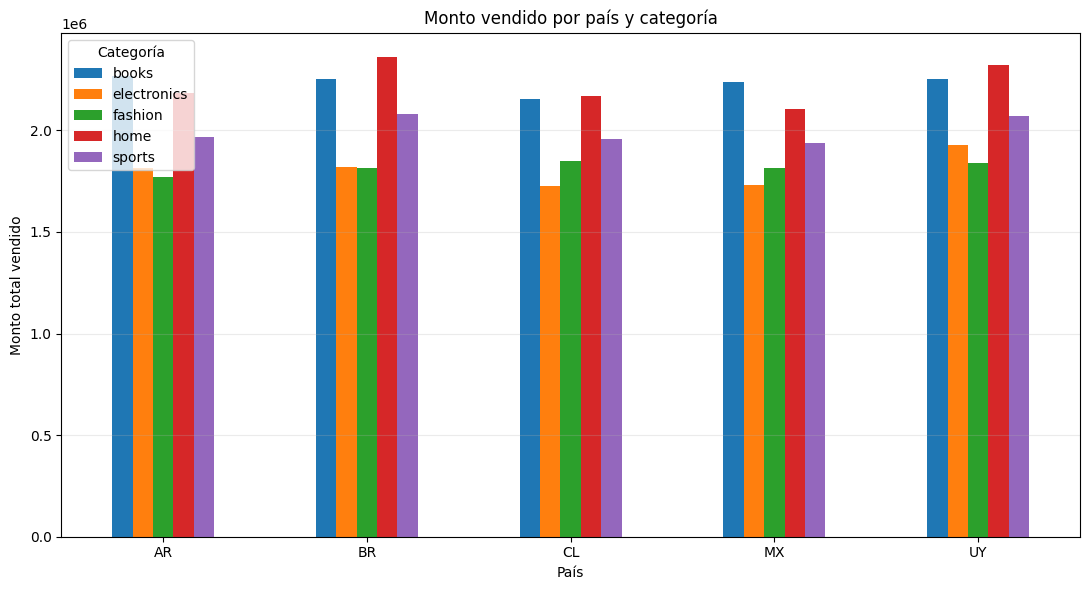

Mayor monto vendido: AR - books (2,267,722.26)

Categoría dominante por país:
AR: books (2,267,722.26)
BR: home (2,361,959.97)
CL: home (2,167,748.03)
MX: books (2,235,941.63)
UY: home (2,323,924.46)


In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

country_category = (spark.table("bigdata_alejo_escalada1.gold_daily_sales")
    .groupBy("country", "category")
    .agg(
        F.sum("total_amount").alias("total_amount")
    )
    .orderBy("country", F.desc("total_amount")))

plot_data = country_category.toPandas()

# Convertimos el monto a numérico para Matplotlib
plot_data["total_amount"] = plot_data["total_amount"].astype(float)

# Reorganizamos para comparar países y categorías
pivot_data = plot_data.pivot(
    index="country",
    columns="category",
    values="total_amount"
)

# Barras agrupadas
ax = pivot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Monto vendido por país y categoría")
ax.set_xlabel("País")
ax.set_ylabel("Monto total vendido")
ax.legend(title="Categoría")
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Máximo global
leader = country_category.first()

print(
    f"Mayor monto vendido: {leader.country} - {leader.category} "
    f"({float(leader.total_amount):,.2f})"
)

# Categoría dominante por país
print("\nCategoría dominante por país:")

for country in plot_data["country"].unique():
    country_data = plot_data[plot_data["country"] == country]
    dominant = country_data.loc[country_data["total_amount"].idxmax()]

    print(
        f"{country}: {dominant['category']} "
        f"({dominant['total_amount']:,.2f})"
    )


## Consigna 4 — Calidad del pipeline

**Pregunta:** ¿Qué proporción de cada lote fue aceptada y rechazada? ¿El lote nuevo presenta una calidad diferente del lote inicial?

Compará lotes usando proporciones además de cantidades absolutas. Señalá cualquier limitación de comparar lotes de tamaños distintos. Fuente sugerida: `gold_batch_summary`.

source_batch_id,accepted_transactions,rejected_transactions,total_amount,fraud_transactions,refreshed_at,total,accepted_pct,rejected_pct
batch_002,200,2,144813.00,27,2026-10-03T13:21:46.503Z,202,99.00990099009901,0.9900990099009901
batch_003,201,2,147014.99,28,2026-10-03T13:21:46.503Z,203,99.01477832512316,0.9852216748768473
initial,49948,51,50139370.34,6560,2026-10-03T13:21:46.503Z,49999,99.8979979599592,0.10200204004080081


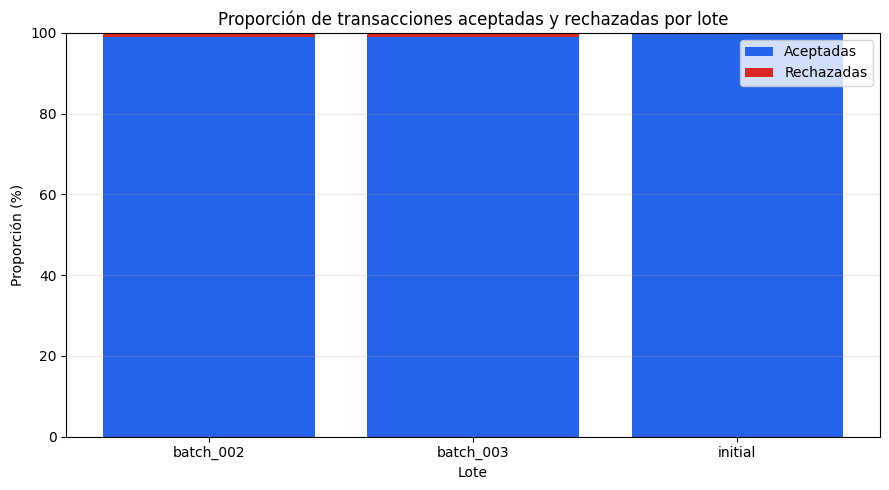

batch_002: 99.01% aceptadas, 0.99% rechazadas (total: 202 transacciones)
batch_003: 99.01% aceptadas, 0.99% rechazadas (total: 203 transacciones)
initial: 99.90% aceptadas, 0.10% rechazadas (total: 49,999 transacciones)
El lote inicial presenta una proporción de 99,90% de transacciones aceptadas y 0,10% rechazadas. En cambio, tanto batch_002 como batch_003 presentan 99,01% aceptadas y 0,99% rechazadas. Por lo tanto, los lotes nuevos tienen una proporción de rechazos mayor que el lote inicial.


In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

batch_quality = (spark.table("bigdata_alejo_escalada1.gold_batch_summary")
    .withColumn(
        "total",
        F.col("accepted_transactions") + F.col("rejected_transactions")
    )
    .withColumn(
        "accepted_pct",
        F.col("accepted_transactions") / F.col("total") * 100
    )
    .withColumn(
        "rejected_pct",
        F.col("rejected_transactions") / F.col("total") * 100
    )
    .orderBy("source_batch_id"))

display(batch_quality)

plot_data = batch_quality.toPandas()

# Barras apiladas al 100%
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    plot_data["source_batch_id"],
    plot_data["accepted_pct"],
    label="Aceptadas",
    color="#2563eb"
)

ax.bar(
    plot_data["source_batch_id"],
    plot_data["rejected_pct"],
    bottom=plot_data["accepted_pct"],
    label="Rechazadas",
    color="#dc2626"
)

ax.set_title("Proporción de transacciones aceptadas y rechazadas por lote")
ax.set_xlabel("Lote")
ax.set_ylabel("Proporción (%)")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Resumen
for _, row in plot_data.iterrows():
    print(
        f"{row['source_batch_id']}: "
        f"{row['accepted_pct']:.2f}% aceptadas, "
        f"{row['rejected_pct']:.2f}% rechazadas "
        f"(total: {int(row['total']):,} transacciones)"
    )
print ("El lote inicial presenta una proporción de 99,90% de transacciones aceptadas y 0,10% rechazadas. En cambio, tanto batch_002 como batch_003 presentan 99,01% aceptadas y 0,99% rechazadas. Por lo tanto, los lotes nuevos tienen una proporción de rechazos mayor que el lote inicial.")

## Criterios de entrega

Para cada consigna entregá: (1) la transformación de datos, (2) un gráfico, y (3) una conclusión de dos o tres oraciones que responda explícitamente la pregunta.

Cada gráfico debe tener título informativo, ejes y unidades legibles, categorías ordenadas cuando corresponda y una elección de color que no sea la única forma de comunicar el significado. No conviertas una tabla Silver completa a Pandas: agregá primero con Spark y convertí sólo el resultado pequeño.